# Taller: Muestreo e inferencia en un sistema de recomendaciones (CTR/CVR)

**Contexto (nuestro ejemplo):** tenemos tres modelos de recomendación **A, B y C**.  
Cada vez que el sistema muestra una recomendación a un usuario ocurre una **impresión** (evento).  
En cada impresión registramos si hubo **clic** (0/1) y si luego hubo **conversión** (0/1).

**Objetivos del taller**
1. Conectar *población, muestra, individuo, variable y dato* con el caso de recomendaciones.
2. Simular una población de impresiones y construir **muestras** con distintos tipos de muestreo (probabilístico y no probabilístico).
3. Calcular **CTR** y **CVR** y comparar modelos.
4. Construir **intervalos de confianza** para CTR.
5. Estimar **tamaño de muestra** necesario para un margen de error dado.
6. Plantear y ejecutar **pruebas de hipótesis** (una cola y dos colas) para comparar CTR.

> **Convención:** trabajaremos principalmente con **impresiones** como *individuos* (unidad de análisis).  
> Entonces, para una impresión: \(X = 1\) si hubo clic y \(X = 0\) si no.  
> En este caso, \(CTR = E[X]\) (promedio de una variable binaria).


## 1) Preparación

Usaremos: `numpy`, `pandas` y `matplotlib`.  
**Regla de visualización:** una gráfica por celda.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt

np.random.seed(42)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True


## 2) Simulación de datos (población de impresiones)

Simularemos una población de impresiones con:
- `model`: A, B o C  
- `user_id`: id de usuario  
- `timestamp`: tiempo (para muestreo sistemático)  
- `country`, `device`, `segment`, `region` (para estratos / conglomerados)  
- `click` (0/1) y `conversion` (0/1, condicionado a click)

Ajustaremos tasas para que:
- el CTR de B sea cercano a 12% (como en el ejemplo de clase),
- C sea ligeramente mejor,
- A ligeramente peor.


In [2]:
N = 200_000  # población grande de impresiones (eventos)
models = np.random.choice(["A", "B", "C"], size=N, p=[0.34, 0.33, 0.33])

# metadatos
user_id = np.random.randint(1, 50_001, size=N)  # 50k usuarios
country = np.random.choice(["MX", "US", "CO", "AR"], size=N, p=[0.55, 0.25, 0.12, 0.08])
device = np.random.choice(["mobile", "desktop"], size=N, p=[0.72, 0.28])
segment = np.random.choice(["new", "returning", "low_activity"], size=N, p=[0.40, 0.45, 0.15])
region = np.random.choice(["north", "center", "south", "west", "east"], size=N)

# timestamps (simulamos una semana, en minutos)
minutes_in_week = 7 * 24 * 60
timestamp_minute = np.random.randint(0, minutes_in_week, size=N)

# probabilidades base de clic por modelo (CTR verdadero de la población)
p_click = {"A": 0.10, "B": 0.12, "C": 0.135}

# pequeños efectos por dispositivo/segmento (para que estratificar tenga sentido)
device_factor = {"mobile": 1.00, "desktop": 0.92}
segment_factor = {"new": 0.95, "returning": 1.05, "low_activity": 0.80}

# probabilidad de clic por impresión
p = np.array([p_click[m] for m in models])     * np.array([device_factor[d] for d in device])     * np.array([segment_factor[s] for s in segment])

p = np.clip(p, 0.001, 0.5)

click = (np.random.rand(N) < p).astype(int)

# probabilidad de conversión dado clic (CVR), depende de modelo
p_conv_given_click = {"A": 0.20, "B": 0.25, "C": 0.27}
q = np.array([p_conv_given_click[m] for m in models])
conversion = ((np.random.rand(N) < q) & (click == 1)).astype(int)

df = pd.DataFrame({
    "model": models,
    "user_id": user_id,
    "timestamp_minute": timestamp_minute,
    "country": country,
    "device": device,
    "segment": segment,
    "region": region,
    "click": click,
    "conversion": conversion
})

df.head()


,model,user_id,timestamp_minute,country,device,segment,region,click,conversion
0,B,44872,3668,MX,mobile,returning,center,0,0
1,C,26634,4194,US,mobile,returning,east,0,0
2,C,12235,7221,CO,mobile,returning,east,0,0
3,B,19536,9225,MX,mobile,returning,north,0,0
4,A,9145,4260,MX,mobile,new,center,0,0


## 3) Conceptos (población, muestra, individuo, variable, dato) en este taller

- **Población:** todas las *impresiones* generadas en el periodo (aquí, todo `df`).
- **Muestra:** subconjunto de impresiones que seleccionamos para estimar métricas.
- **Individuo:** una impresión (una fila del dataset).
- **Variables:** `click` y `conversion` (y metadatos como `country`, `device`, etc.).
- **Dato:** por ejemplo, en la impresión #814, `click=1` y `conversion=0`.

En lo que sigue, construiremos diferentes muestras para ver cómo cambia (o se sesga) la estimación del CTR/CVR.


## 4) Métricas del *universo* (solo para referencia)

En la práctica no conoceríamos los valores verdaderos; aquí los calculamos para comparar con las estimaciones de las muestras.


In [3]:
def metrics_by_model(data: pd.DataFrame) -> pd.DataFrame:
    g = data.groupby("model").agg(
        impressions=("click", "size"),
        clicks=("click", "sum"),
        conversions=("conversion", "sum")
    )
    g["CTR"] = g["clicks"] / g["impressions"]
    g["CVR"] = np.where(g["clicks"] > 0, g["conversions"] / g["clicks"], np.nan)
    return g.sort_index()

true_metrics = metrics_by_model(df)
true_metrics


,impressions,clicks,conversions,CTR,CVR
model,,,,,
A,67911,6501,1334,0.095728,0.205199
B,66069,7495,1888,0.113442,0.251901
C,66020,8435,2199,0.127764,0.260699


Un histograma rápido de la variable `click` (binaria) y un conteo por modelo.

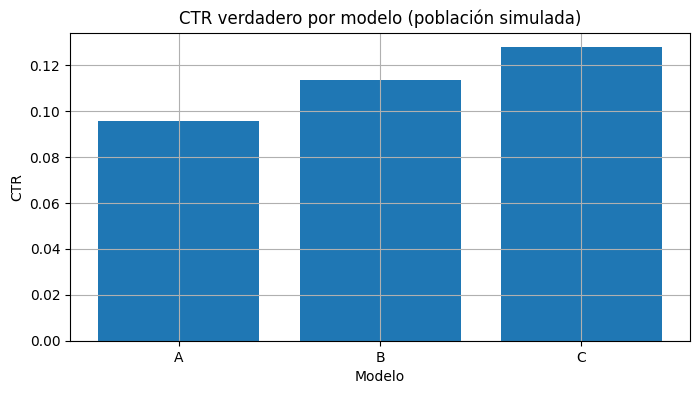

In [4]:
counts = df.groupby("model")["click"].mean().rename("CTR_true").reset_index()

plt.figure()
plt.bar(counts["model"], counts["CTR_true"])
plt.title("CTR verdadero por modelo (población simulada)")
plt.xlabel("Modelo")
plt.ylabel("CTR")
plt.show()


## 5) Muestreo probabilístico (sobre impresiones)

Vamos a construir muestras de tamaño similar (por ejemplo, 3000 impresiones) usando:
- Aleatorio simple
- Sistemático (por tiempo)
- Estratificado (por país)
- Por conglomerados (por región)

Luego estimaremos CTR y CVR con cada muestra.


In [5]:
def sample_simple_random(data: pd.DataFrame, n: int) -> pd.DataFrame:
    return data.sample(n=n, replace=False, random_state=42)

def sample_systematic_by_time(data: pd.DataFrame, n: int) -> pd.DataFrame:
    # ordena por tiempo y toma cada k-ésima fila después de un arranque aleatorio
    d = data.sort_values("timestamp_minute").reset_index(drop=True)
    k = max(len(d) // n, 1)
    start = np.random.randint(0, k)
    idx = np.arange(start, start + k*n, k)
    idx = idx[idx < len(d)]
    return d.loc[idx].copy()

def sample_stratified(data: pd.DataFrame, n: int, strata_col: str) -> pd.DataFrame:
    # proporcional al tamaño del estrato
    parts = []
    counts = data[strata_col].value_counts(normalize=True)
    for level, prop in counts.items():
        n_level = max(int(round(n * prop)), 1)
        part = data[data[strata_col] == level].sample(n=min(n_level, (data[strata_col]==level).sum()),
                                                      random_state=42)
        parts.append(part)
    out = pd.concat(parts, axis=0).sample(n=min(n, sum(len(p) for p in parts)), random_state=42)
    return out

def sample_cluster(data: pd.DataFrame, n_clusters: int, cluster_col: str) -> pd.DataFrame:
    clusters = np.random.choice(data[cluster_col].unique(), size=n_clusters, replace=False)
    out = data[data[cluster_col].isin(clusters)].copy()
    return out

n_target = 3000

s_simple = sample_simple_random(df, n_target)
s_syst   = sample_systematic_by_time(df, n_target)
s_strat  = sample_stratified(df, n_target, "country")
s_cluster_full = sample_cluster(df, n_clusters=2, cluster_col="region")  # puede salir mucho más de 3000
s_cluster = s_cluster_full.sample(n=min(n_target, len(s_cluster_full)), random_state=42)

samples_prob = {
    "Aleatorio simple": s_simple,
    "Sistemático (tiempo)": s_syst,
    "Estratificado (país)": s_strat,
    "Conglomerados (región)": s_cluster,
}

pd.DataFrame({name: [len(s)] for name, s in samples_prob.items()})


,Aleatorio simple,Sistemático (tiempo),Estratificado (país),Conglomerados (región)
0,3000,3000,3000,3000


### 5.1) Estimaciones de CTR/CVR por tipo de muestreo

In [6]:
rows = []
for name, s in samples_prob.items():
    m = metrics_by_model(s)
    m["sampling"] = name
    rows.append(m.reset_index())

est_prob = pd.concat(rows, ignore_index=True)
est_prob.pivot_table(index=["model"], columns="sampling", values="CTR")


sampling,Aleatorio simple,Conglomerados (región),Estratificado (país),Sistemático (tiempo)
model,,,,
A,0.097126,0.098492,0.093966,0.091977
B,0.105263,0.114201,0.122222,0.120925
C,0.123316,0.125251,0.132132,0.132425


Observa cómo algunas estrategias pueden introducir sesgo si la variable depende del tiempo/segmento/país.
Compararemos con el CTR verdadero (población).

In [7]:
ctr_true = true_metrics["CTR"].rename("CTR_true").reset_index()
ctr_est = est_prob[["model","sampling","CTR"]]
merged = ctr_est.merge(ctr_true, on="model")
merged["error"] = merged["CTR"] - merged["CTR_true"]
merged.sort_values(["sampling","model"]).head(12)


,model,sampling,CTR,CTR_true,error
0,A,Aleatorio simple,0.097126,0.095728,0.001398
1,B,Aleatorio simple,0.105263,0.113442,-0.008179
2,C,Aleatorio simple,0.123316,0.127764,-0.004448
9,A,Conglomerados (región),0.098492,0.095728,0.002764
10,B,Conglomerados (región),0.114201,0.113442,0.000759
11,C,Conglomerados (región),0.125251,0.127764,-0.002514
6,A,Estratificado (país),0.093966,0.095728,-0.001762
7,B,Estratificado (país),0.122222,0.113442,0.008780
8,C,Estratificado (país),0.132132,0.127764,0.004368
3,A,Sistemático (tiempo),0.091977,0.095728,-0.003752


## 6) Muestreo no probabilístico (sobre impresiones)

Ejemplos adaptados al caso:
- Conveniencia: primeras impresiones del día (o de la semana)
- Intencional: impresiones de usuarios frecuentes (segmento returning)
- Por cuotas: fijar % por segmento
- “Bola de nieve”: aquí lo simularemos como *beta cerrada* con usuarios muy activos

**Nota:** aquí no conocemos probabilidades de selección, así que el sesgo puede ser mayor.


In [8]:
def sample_convenience_first(data: pd.DataFrame, n: int) -> pd.DataFrame:
    # primeras impresiones por tiempo
    d = data.sort_values("timestamp_minute").head(n).copy()
    return d

def sample_purposive_returning(data: pd.DataFrame, n: int) -> pd.DataFrame:
    d = data[data["segment"] == "returning"]
    return d.sample(n=min(n, len(d)), random_state=42)

def sample_quota_segment(data: pd.DataFrame, n: int, quota: dict) -> pd.DataFrame:
    parts = []
    for seg, prop in quota.items():
        n_seg = int(round(n * prop))
        d = data[data["segment"] == seg]
        parts.append(d.sample(n=min(n_seg, len(d)), random_state=42))
    out = pd.concat(parts, axis=0)
    if len(out) > n:
        out = out.sample(n=n, random_state=42)
    return out

def sample_snowball_beta(data: pd.DataFrame, n_users_seed: int, n: int) -> pd.DataFrame:
    # "usuarios power": los que más impresiones tienen en la población simulada
    top_users = data["user_id"].value_counts().head(500).index.to_numpy()
    seeds = np.random.choice(top_users, size=n_users_seed, replace=False)
    # "reclutamiento": añadimos usuarios de la misma región que los seeds (proxy)
    seed_regions = data[data["user_id"].isin(seeds)]["region"].unique()
    pool = data[data["region"].isin(seed_regions)]
    return pool.sample(n=min(n, len(pool)), random_state=42)

n_target = 3000
s_conv  = sample_convenience_first(df, n_target)
s_int   = sample_purposive_returning(df, n_target)
s_quota = sample_quota_segment(df, n_target, {"new":0.40, "returning":0.40, "low_activity":0.20})
s_snow  = sample_snowball_beta(df, n_users_seed=30, n=n_target)

samples_nonprob = {
    "Conveniencia": s_conv,
    "Intencional (returning)": s_int,
    "Cuotas (segmento)": s_quota,
    "Bola de nieve (beta)": s_snow
}

rows = []
for name, s in samples_nonprob.items():
    m = metrics_by_model(s)
    m["sampling"] = name
    rows.append(m.reset_index())

est_nonprob = pd.concat(rows, ignore_index=True)
est_nonprob.pivot_table(index="model", columns="sampling", values="CTR")


sampling,Bola de nieve (beta),Conveniencia,Cuotas (segmento),Intencional (returning)
model,,,,
A,0.097126,0.096339,0.088645,0.107396
B,0.105263,0.102161,0.112103,0.111550
C,0.123316,0.122881,0.126518,0.125000


## 7) Valor esperado y varianza: por qué aparece \(p(1-p)\)

Para una impresión, \(X=1\) si hay clic y \(X=0\) si no.

- \(E[X]=p\) (que es el CTR en proporción)
- \(\mathrm{Var}(X)=p(1-p)\)
- \(\sigma=\sqrt{p(1-p)}\)

Verificaremos esto con el Modelo B usando su CTR estimado en la población.


In [9]:
pB = true_metrics.loc["B","CTR"]
varB = pB*(1-pB)
sigmaB = sqrt(varB)
pB, varB, sigmaB


(np.float64(0.11344200759811712),
 np.float64(0.10057291851022587),
 0.31713233595807583)

## 8) Tamaño de muestra para estimar CTR con margen de error \(e\)

Si queremos un IC del 95% para \(p\) con margen de error \(e\) (en proporción), usamos:
\[
n \ge \frac{z_{0.975}^2\,p(1-p)}{e^2}
\]
Si no conocemos \(p\), usamos \(p=0.5\) (peor caso).

Calculemos \(n\) para estimar un CTR alrededor de 12% con \(e=0.02\) (2 puntos porcentuales).


In [10]:
z = 1.96
p = 0.12
e = 0.02
n_needed = (z**2 * p*(1-p)) / (e**2)
n_needed


1014.1823999999999

## 9) Intervalo de confianza para CTR (proporción)

Con una muestra de tamaño \(n\) y \(\hat p\) observado:
\[
IC_{95\%} = \hat p \pm 1.96\sqrt{\frac{\hat p(1-\hat p)}{n}}
\]

Construyamos el IC para el Modelo B usando una muestra aleatoria simple de \(n=1000\) impresiones.


In [11]:
sB = s_simple[s_simple["model"]=="B"].copy()
# Si en la muestra aleatoria hay menos de 1000 impresiones B, tomamos 1000 del universo de B aleatoriamente
if len(sB) < 1000:
    sB = df[df["model"]=="B"].sample(n=1000, random_state=42)
else:
    sB = sB.sample(n=1000, random_state=42)

n = len(sB)
phat = sB["click"].mean()

se = sqrt(phat*(1-phat)/n)
ci_low, ci_high = phat - 1.96*se, phat + 1.96*se
(phat, n, ci_low, ci_high)


(np.float64(0.106),
 1000,
 np.float64(0.0869200266666853),
 np.float64(0.1250799733333147))

## 10) Pruebas de hipótesis: una cola vs dos colas (comparando CTR)

### 10.1) Contra un baseline (una proporción)
Ejemplo: para el Modelo B queremos probar si el CTR es mayor que 0.12.

- \(H_0: p = 0.12\)
- \(H_1: p > 0.12\) (cola derecha)

Usamos estadístico Z:
\[
Z = \frac{\hat p - p_0}{\sqrt{p_0(1-p_0)/n}}
\]
y rechazamos si \(Z > z_{0.95}=1.645\) (para \(lpha=0.05\), una cola).


In [12]:
from math import erf

def norm_cdf(x):
    return 0.5*(1+erf(x/sqrt(2)))

p0 = 0.12
z_stat = (phat - p0) / sqrt(p0*(1-p0)/n)
p_value_right = 1 - norm_cdf(z_stat)  # p-valor cola derecha
z_crit_right = 1.645

z_stat, p_value_right, z_crit_right


(np.float64(-1.362373152282665), 0.9134599239281034, 1.645)

### 10.2) Comparación entre dos modelos (diferencia de proporciones)

Para comparar B vs A (¿B mejora a A?):
- \(H_0: p_B = p_A\)
- \(H_1: p_B > p_A\) (cola derecha)

Usamos el test Z con proporción combinada:
\[
\hat p = \frac{x_A + x_B}{n_A + n_B},\quad
SE = \sqrt{\hat p(1-\hat p)\left(\frac{1}{n_A}+\frac{1}{n_B}\right)}
\]
\[
Z = \frac{\hat p_B - \hat p_A}{SE}
\]


In [13]:
def two_prop_z_test(x1, n1, x2, n2, alternative="two-sided"):
    p1 = x1/n1
    p2 = x2/n2
    p_pool = (x1+x2)/(n1+n2)
    se = sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))
    z = (p2 - p1)/se  # (2 - 1)
    if alternative == "greater":   # p2 > p1
        pval = 1 - norm_cdf(z)
    elif alternative == "less":    # p2 < p1
        pval = norm_cdf(z)
    else:
        pval = 2*(1 - norm_cdf(abs(z)))
    return z, pval, p1, p2

# tomamos una muestra aleatoria simple por modelo (misma n por simplicidad)
n_each = 2000
sA = df[df["model"]=="A"].sample(n=n_each, random_state=1)
sB2 = df[df["model"]=="B"].sample(n=n_each, random_state=2)

xA, xB = sA["click"].sum(), sB2["click"].sum()
zBA, pBA, pA_hat, pB_hat = two_prop_z_test(x1=xA, n1=n_each, x2=xB, n2=n_each, alternative="greater")

zBA, pBA, pA_hat, pB_hat


(np.float64(1.3983857960705814),
 0.08099862309445538,
 np.float64(0.106),
 np.float64(0.12))

## 11) Mini-ejercicios (para entregar)

Crea celdas nuevas y responde:

1. **Muestreo:** construye una muestra estratificada por `device` (móvil/escritorio) de tamaño 3000.  
   - Reporta el CTR estimado por modelo.
2. **Sesgo:** compara el muestreo por conveniencia vs aleatorio simple:  
   - ¿En cuál hay mayor error absoluto respecto al CTR verdadero?
3. **IC:** para el Modelo C, toma una muestra aleatoria de 1500 impresiones y calcula el IC 95% del CTR.  
4. **Prueba de hipótesis (dos colas):** ¿el CTR de C es distinto del de B?  
   - Usa el test de diferencia de proporciones con $\alpha=0.05$.
5. **Tamaño de muestra:** si quieres un margen de error de 1 punto porcentual ($e=0.01$) y esperas $p=0.12$, ¿cuántas impresiones necesitas por modelo?


#Alumno: Octavio Quintero Flores
#Matricula: 266226
##1 Muestreo

In [15]:
print(df.columns)

Index(['model', 'user_id', 'timestamp_minute', 'country', 'device', 'segment',
       'region', 'click', 'conversion'],
      dtype='object')


In [16]:
# Muestreo estratificado por dispositivo

n = 3000

# proporción de cada device
prop = df['device'].value_counts(normalize=True)

n_mobile = int(prop['mobile'] * n)
n_desktop = n - n_mobile

# muestras por estrato
sample_mobile = df[df['device'] == 'mobile'].sample(n=n_mobile, random_state=42)
sample_desktop = df[df['device'] == 'desktop'].sample(n=n_desktop, random_state=42)

# unir muestras
sample_strat = pd.concat([sample_mobile, sample_desktop])

# CTR por modelo
ctr_strat = sample_strat.groupby('model')['click'].mean()

print("CTR estimado por modelo:")
print(ctr_strat)

CTR estimado por modelo:
model
A    0.099206
B    0.121608
C    0.119358
Name: click, dtype: float64


##2 Sesgo

In [17]:
# Muestreo por conveniencia (primeras 3000 filas)
sample_conv = df.head(3000)
ctr_conv = sample_conv['click'].mean()

# Muestreo aleatorio simple
sample_rand = df.sample(3000, random_state=42)
ctr_rand = sample_rand['click'].mean()

# CTR verdadero de toda la población
ctr_true = df['click'].mean()

# Error absoluto
error_conv = abs(ctr_conv - ctr_true)
error_rand = abs(ctr_rand - ctr_true)

print("CTR verdadero:", ctr_true)
print("CTR conveniencia:", ctr_conv)
print("CTR aleatorio:", ctr_rand)

print("Error absoluto conveniencia:", error_conv)
print("Error absoluto aleatorio:", error_rand)

CTR verdadero: 0.112155
CTR conveniencia: 0.11033333333333334
CTR aleatorio: 0.10833333333333334
Error absoluto conveniencia: 0.0018216666666666659
Error absoluto aleatorio: 0.0038216666666666677


En esta muestra, el muestreo por conveniencia produjo una estimación más cercana al CTR verdadero.

##3 IC

In [18]:
import numpy as np
from scipy.stats import norm

# muestra aleatoria del modelo C
sample_c = df[df['model'] == 'C'].sample(1500, random_state=42)

# CTR estimado
p_hat = sample_c['click'].mean()

# tamaño de muestra
n = len(sample_c)

# valor z para 95%
z = norm.ppf(0.975)

# error estándar
se = np.sqrt(p_hat * (1 - p_hat) / n)

# intervalo de confianza
ci_lower = p_hat - z * se
ci_upper = p_hat + z * se

print("CTR estimado:", p_hat)
print("Intervalo de confianza 95%:", (ci_lower, ci_upper))

CTR estimado: 0.12666666666666668
Intervalo de confianza 95%: (np.float64(0.10983513452566535), np.float64(0.143498198807668))


Se tomó una muestra aleatoria de 1500 impresiones del modelo C y se estimó el CTR.
Luego se calculó un intervalo de confianza del 95%, que representa el rango donde probablemente se encuentra el CTR verdadero de la población.

##4 Prueba de hipotesis


In [19]:
from statsmodels.stats.proportion import proportions_ztest

# clics por modelo
clicks_C = df[df['model'] == 'C']['click'].sum()
clicks_B = df[df['model'] == 'B']['click'].sum()

# impresiones por modelo
n_C = len(df[df['model'] == 'C'])
n_B = len(df[df['model'] == 'B'])

clicks = [clicks_C, clicks_B]
impressions = [n_C, n_B]

# test de proporciones
z_stat, p_value = proportions_ztest(clicks, impressions)

print("z statistic:", z_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Se rechaza H0: el CTR de C es distinto del de B")
else:
    print("No se rechaza H0")

z statistic: 7.991873269590305
p-value: 1.3290362243643466e-15
Se rechaza H0: el CTR de C es distinto del de B


Si el p-value es menor que 0.05, existe evidencia de que los CTR de los modelos C y B son diferentes.

##5Tamaño de la muestra

In [20]:
import math

z = 1.96
p = 0.12
e = 0.01

n = (z**2 * p * (1 - p)) / (e**2)

print("Tamaño de muestra necesario por modelo:", math.ceil(n))

Tamaño de muestra necesario por modelo: 4057


Se requieren alrededor de 4057 impresiones por modelo para estimar el CTR con el nivel de precisión deseado.